# Q-Learning on CliffWalking

Tabular Q-learning implemented from scratch for the Gymnasium [CliffWalking-v0](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) environment: Q-table construction, an epsilon-greedy policy, the Bellman update rule, and a 10,000-episode training loop with epsilon decay. Episodes are recorded on video with the `RecordVideo` wrapper, and the learned Q-table and reward curve are analyzed.

*Coursework - BSc in Applied Data Science, Universitat Oberta de Catalunya (UOC), Machine Learning course. Narrative translated to English from the original Spanish; printed outputs and figure labels are shown as originally executed (in Spanish).*

## 1. Environment setup and exploration

In [1]:
!pip install gymnasium

import gymnasium as gym

### Creating the environment

CliffWalking-v0 is a 4x12 grid world: the agent starts at the bottom-left corner and must reach the bottom-right goal without stepping off the cliff that spans the bottom row.

In [3]:
env = gym.make('CliffWalking-v0')

The environment is a 4x12 grid, which means there are 4 rows and 12 columns.

The agent starts in the bottom-left corner (position [3, 0]) and its goal is to reach the bottom-right corner (position [3, 11]).

The agent can make four types of moves: up, down, left and right. These actions are encoded as 0, 1, 2 and 3, respectively.

For each move, the agent receives a reward of -1, penalizing the time it takes to reach the goal.

If the agent falls off the cliff (any position in the bottom row except the start and goal positions), it receives a penalty of -100 and is sent back to the starting position.

States:

The states represent the agent's positions on the grid. There are a total of 48 possible states (4 rows x 12 columns).

The agent's objective is to find the most efficient route (that is, with the lowest possible penalty) from the starting point to the goal, while avoiding falling off the cliff.


The environment is deterministic, which means that the agent's actions always have a predictable outcome and there are no elements of chance in the transition between states.


When it falls off the cliff, in addition to receiving a penalty of -100, the agent is transported back to the starting position. This is crucial for understanding how the agent must learn to avoid these penalized states.


### State and action spaces

In [4]:
# We get the number of states of the environment
obs_space = env.observation_space.n

# We get the number of possible actions
num_actions = env.action_space.n

# We get the range of values of the possible rewards
rwd_range = env.reward_range

print('obs_space:', obs_space)
print('#actions:', num_actions)
print('rwd_range:', rwd_range)


obs_space: 48
#actions: 4
rwd_range: (-inf, inf)


### Recording episodes with the RecordVideo wrapper

In [5]:
from gymnasium.wrappers import RecordVideo

# We create the environment with the appropriate render mode
env = gym.make('CliffWalking-v0', render_mode='rgb_array')

# We apply the RecordVideo wrapper to record all the episodes
env = RecordVideo(env, video_folder="videos", episode_trigger=lambda episode_id: True)

# We run an episode to test the recording
observation, info = env.reset()
done = False
while not done:
    action = env.action_space.sample()  # Take a random action
    observation, reward, done, truncated, info = env.step(action)

print("El entorno ha sido configurado para grabar vídeos de todos los episodios.")

/usr/local/lib/python3.10/dist-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Moviepy - Building video /content/videos/rl-video-episode-0.mp4.
Moviepy - Writing video /content/videos/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/rl-video-episode-0.mp4
El entorno ha sido configurado para grabar vídeos de todos los episodios.


Gym wrappers are tools that make it possible to modify and extend the functionality of an environment without changing its underlying implementation. Wrappers are used for various tasks, such as preprocessing observations, modifying rewards, recording episodes, and applying specific RL techniques.


### Baseline episode: always moving up

In [6]:
import moviepy.editor as mpy
import os


# We run an episode with a maximum of 50 iterations in which the agent always moves up
observation, info = env.reset()
done = False
steps = 0

while not done and steps < 50:
    action = 0  # Upward action
    observation, reward, done, truncated, info = env.step(action)
    steps += 1

# We close the environment to make sure the video is saved correctly
env.close()

print("El entrenamiento ha sido completado y el vídeo ha sido grabado.")


print("El entrenamiento ha sido completado y el vídeo ha sido grabado.")

# We load and display the training video
video_path = env.video_recorder.path
video = mpy.VideoFileClip(video_path)
video.ipython_display(width=600)



Moviepy - Building video /content/videos/rl-video-episode-1.mp4.
Moviepy - Writing video /content/videos/rl-video-episode-1.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/rl-video-episode-1.mp4
El entrenamiento ha sido completado y el vídeo ha sido grabado.
El entrenamiento ha sido completado y el vídeo ha sido grabado.
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


The agent moves from its starting position toward the top of the grid, going up one row at each step.


Each upward move will result in a reward of -1 for each step due to the time penalty.

Since the agent only moves up, it will eventually reach the upper boundary of the grid and will stay in the top row until the maximum number of steps is completed or the episode ends.

This behavior is suboptimal because it does not consider the objective of reaching the goal and avoiding the cliff. The agent simply moves up without taking into account the total reward or the optimal strategy.
This basic training illustrates the importance of defining a suitable policy so that the agent can learn to maximize its total reward. In this case, the agent does not achieve its objective because of the limited movement policy.








### Baseline episode: random policy

In [7]:
# We run an episode with a maximum of 50 iterations in which the agent makes random moves
observation, info = env.reset()
done = False
steps = 0

while not done and steps < 50:
    action = env.action_space.sample()  # Take a random action
    observation, reward, done, truncated, info = env.step(action)
    steps += 1

# We close the environment to make sure the video is saved correctly
env.close()

print("El entrenamiento ha sido completado y el vídeo ha sido grabado.")

# We load and display the training video
video_path = env.video_recorder.path
video = mpy.VideoFileClip(video_path)
video.ipython_display(width=600)


Moviepy - Building video /content/videos/rl-video-episode-1.mp4.
Moviepy - Writing video /content/videos/rl-video-episode-1.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/rl-video-episode-1.mp4
El entrenamiento ha sido completado y el vídeo ha sido grabado.
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


The agent moves in random directions at each step, which means it could move up, down, left or right without a defined pattern.

Each move will result in a reward of -1 due to the time penalty.
If the agent falls off the cliff, it will receive a penalty of -100 and will be sent back to the starting position, which can be observed in the video if it happens.

Due to the random nature of the moves, the agent may take a long time to reach the goal, if it manages to do so at all within the 50-step limit.
It is likely that the agent will move inefficiently and may fall off the cliff several times, which will be reflected in the video as moves toward the edge of the cliff and resets to the starting position.
Suboptimal behavior:

Random behavior is not efficient for reaching the goal. Although it is useful for exploring the environment, it does not guarantee an effective strategy for maximizing the total reward.

## 2. Q-learning implementation

### Q-table initialization

In [8]:
import numpy as np

def create_q_table(env):
    # We get the number of states and actions of the environment
    num_states = env.observation_space.n
    num_actions = env.action_space.n

    # We create the Q-table with dimensions (num_states, num_actions) and initialize it with zeros
    q_table = np.zeros((num_states, num_actions))

    return q_table

### Epsilon-greedy action selection

In [9]:
import random

def get_action(state, env, q_table, epsilon):
    # We generate a random number
    random_value = np.random.uniform(0, 1)

    if random_value < epsilon:
        # We select a random action (exploration)
        action = env.action_space.sample()
    else:
        # We select the optimal action based on the Q-table (exploitation)
        action = np.argmax(q_table[state])

    return action


### Bellman update

In [10]:
def update_q_table(q_table, state, next_state, action, reward, learning_rate, discount):
    # We get the Q-values of the next state
    next_state_q_values = q_table[next_state]

    # We find the best Q-value for the next state
    best_next_action = np.argmax(next_state_q_values)
    best_next_q_value = next_state_q_values[best_next_action]

    # We get the current Q-value for the given state and action
    current_q_value = q_table[state, action]

    # We update the Q-value using the Bellman equation
    q_table[state, action] = current_q_value + learning_rate * (reward + discount * best_next_q_value - current_q_value)

    return q_table

### Training loop

In [11]:
def rl_loop(env, n_episodes, learning_rate, epsilon_init, epsilon_decay, discount):
    # We initialize the Q-table
    q_table = create_q_table(env)
    # List to store the total rewards per episode
    episode_total_rewards = []
    # We initialize epsilon
    epsilon = epsilon_init

    for episode in range(n_episodes):
        # We reset the environment and get the initial state
        state, info = env.reset()
        done = False
        total_rewards = 0

        while not done:
            # Select an action using the epsilon-greedy policy
            action = get_action(state, env, q_table, epsilon)
            # Execute the action in the environment
            next_state, reward, done, truncated, info = env.step(action)
            # We update the Q-table
            q_table = update_q_table(q_table, state, next_state, action, reward, learning_rate, discount)
            # We update the current state
            state = next_state
            # We add the reward
            total_rewards += reward

        # We store the total reward of this episode
        episode_total_rewards.append(total_rewards)
        # Decrease epsilon, making sure it is not less than zero
        epsilon = max(0, epsilon - epsilon_decay)

        # We print the progress
        if (episode + 1) % 100 == 0:
            print(f"Episodio {episode + 1}/{n_episodes} - Recompensa Total: {total_rewards}")

    return q_table, episode_total_rewards

### Training the agent: 10,000 episodes with epsilon decay

In [12]:
N_EPISODES = 10000
LEARNING_RATE = 0.9
EPSILON_INIT = 1
EPSILON_DECAY = 0.0001
DISCOUNT = 0.9

In [13]:
# We create the environment with the appropriate render mode
env = gym.make('CliffWalking-v0', render_mode='rgb_array')

# We apply the RecordVideo wrapper to record the first and the last episode.
video_folder = "videos_1"
if not os.path.exists(video_folder):
    os.makedirs(video_folder)

env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda episode_id: episode_id == 0 or episode_id == N_EPISODES - 1)
# We train the agent
q_table, episode_total_rewards = rl_loop(env, N_EPISODES, LEARNING_RATE, EPSILON_INIT, EPSILON_DECAY, DISCOUNT)

# Close the environment correctly
env.close()

# We print the trained Q-table and the rewards obtained in the episodes
print("Trained Q-table:")
print(q_table)
print("Rewards per episode:")
print(episode_total_rewards)

# We load and show the video of the first and last episode
video_files = [f for f in os.listdir(video_folder) if f.endswith('.mp4')]
for video_file in video_files:
    video_path = os.path.join(video_folder, video_file)
    print(f"Video file found: {video_path}")
    video = mpy.VideoFileClip(video_path)
    video.ipython_display(width=600, maxduration=120000)

  logger.warn(



Moviepy - Building video /content/videos_1/rl-video-episode-0.mp4.
Moviepy - Writing video /content/videos_1/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /content/videos_1/rl-video-episode-0.mp4
Episodio 100/10000 - Recompensa Total: -7893
Episodio 200/10000 - Recompensa Total: -15004
Episodio 300/10000 - Recompensa Total: -8805
Episodio 400/10000 - Recompensa Total: -7905
Episodio 500/10000 - Recompensa Total: -31659
Episodio 600/10000 - Recompensa Total: -4480
Episodio 700/10000 - Recompensa Total: -2786
Episodio 800/10000 - Recompensa Total: -1617
Episodio 900/10000 - Recompensa Total: -9769
Episodio 1000/10000 - Recompensa Total: -5957
Episodio 1100/10000 - Recompensa Total: -16009
Episodio 1200/10000 - Recompensa Total: -1626
Episodio 1300/10000 - Recompensa Total: -3390
Episodio 1400/10000 - Recompensa Total: -3551
Episodio 1500/10000 - Recompensa Total: -3222
Episodio 1600/10000 - Recompensa Total: -5232
Episodio 1700/10000 - Recompensa Total: -1008
Episodio 1800/10000 - Recompensa Total: -352
Episodio 1900/10000 - Recompensa Total: -9724
Episodio 2000/10000 - Recompensa Total: -918
Episodio

Moviepy - Done !
Moviepy - video ready /content/videos_1/rl-video-episode-9999.mp4
Episodio 10000/10000 - Recompensa Total: -13
Trained Q-table:
[[  -7.94108868   -7.71232075   -7.71232075   -7.94108868]
 [  -7.71232075   -7.45813417   -7.45813417   -7.94108868]
 [  -7.45813417   -7.17570464   -7.17570464   -7.71232075]
 [  -7.17570464   -6.86189404   -6.86189404   -7.45813417]
 [  -6.86189404   -6.5132156    -6.5132156    -7.17570464]
 [  -6.5132156    -6.12579511   -6.12579511   -6.86189404]
 [  -6.12579511   -5.6953279    -5.6953279    -6.5132156 ]
 [  -5.6953279    -5.217031     -5.217031     -6.12579511]
 [  -5.217031     -4.68559      -4.68559      -5.6953279 ]
 [  -4.68559      -4.0951       -4.0951       -5.217031  ]
 [  -4.0951       -3.439        -3.439        -4.68559   ]
 [  -3.439        -3.439        -2.71         -4.0951    ]
 [  -7.94108868   -7.45813417   -7.45813417   -7.71232075]
 [  -7.71232075   -7.17570464   -7.17570464   -7.71232075]
 [  -7.45813417   -6.86189404

Moviepy - Done !
Moviepy - video ready __temp__.mp4
Video file found: videos_1/rl-video-episode-9999.mp4
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


### Reward evolution during training

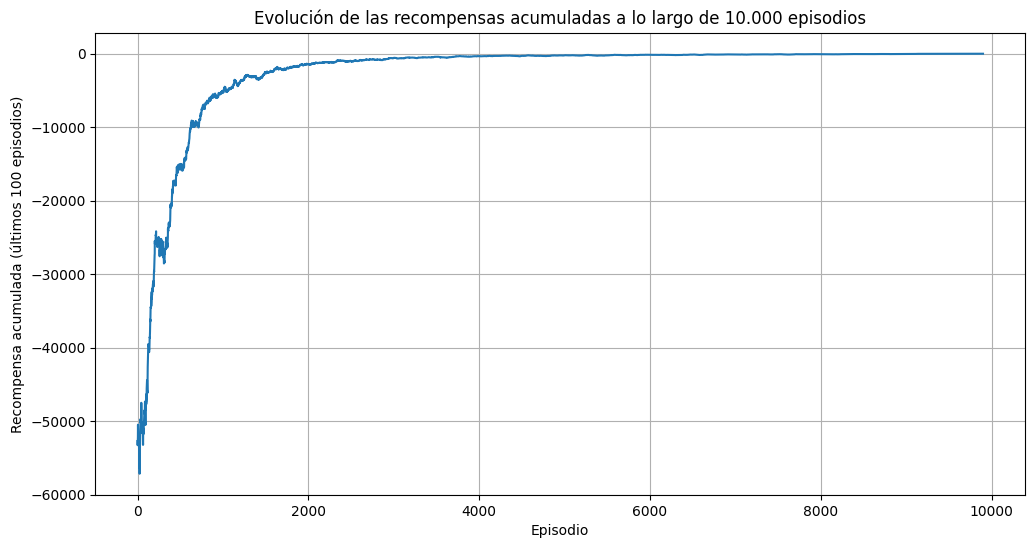

In [14]:
import matplotlib.pyplot as plt
# We compute the accumulated rewards over the last 100 episodes
accumulated_rewards = np.convolve(episode_total_rewards, np.ones(100)/100, mode='valid')

# We plot the accumulated rewards
plt.figure(figsize=(12, 6))
plt.plot(accumulated_rewards)
plt.xlabel('Episodio')
plt.ylabel('Recompensa acumulada (últimos 100 episodios)')
plt.title('Evolución de las recompensas acumuladas a lo largo de 10.000 episodios')
plt.grid(True)
plt.show()


At the start (first 1000 episodes), the accumulated reward is extremely negative, which indicates that the agent is making suboptimal decisions and suffering large penalties. This is typical at the start of training, where the agent explores the environment and has not yet learned an effective policy.

A significant improvement in the accumulated rewards is observed during the first 1000 episodes. The slope of the curve is very steep, which suggests that the agent is quickly learning to avoid falls off the cliff and to obtain higher rewards.
Stabilization:

From approximately 2000 episodes onward, the curve begins to stabilize and a slower but steady improvement in the accumulated rewards is observed. This indicates that the agent has learned the basic strategies for avoiding large penalties, but is still refining its policy.

After about 4000 episodes, the accumulated reward stabilizes and shows little variability. The curve is practically horizontal at this point, which suggests that the agent has converged to a policy close to the optimal one.

The stabilization of the curve suggests that the agent has learned an effective policy and has reached a point of convergence. The absence of large fluctuations in the accumulated reward indicates that the agent is consistently maximizing rewards and minimizing penalties.

The rapid initial improvement followed by a stabilization suggests that the reinforcement learning algorithm used is effective at teaching the agent to navigate the "CliffWalking-v0" environment. The initial exploration phase is followed by an exploitation phase where the agent refines its policy.

### Learned Q-table and final policy

In [15]:
from matplotlib import animation
from IPython.display import display, HTML
import pandas as pd
import moviepy.editor as mpy

# We show the Q-table
q_table_df = pd.DataFrame(q_table, columns=["Izquierda", "Abajo", "Derecha", "Arriba"])
print("Tabla Q entrenada:")
display(q_table_df)

video_path = env.video_recorder.path
video = mpy.VideoFileClip(video_path)
video.ipython_display(width=600)

Tabla Q entrenada:


,Izquierda,Abajo,Derecha,Arriba
0,-7.941089,-7.712321,-7.712321,-7.941089
1,-7.712321,-7.458134,-7.458134,-7.941089
2,-7.458134,-7.175705,-7.175705,-7.712321
3,-7.175705,-6.861894,-6.861894,-7.458134
4,-6.861894,-6.513216,-6.513216,-7.175705
5,-6.513216,-6.125795,-6.125795,-6.861894
6,-6.125795,-5.695328,-5.695328,-6.513216
7,-5.695328,-5.217031,-5.217031,-6.125795
8,-5.217031,-4.685590,-4.685590,-5.695328
9,-4.685590,-4.095100,-4.095100,-5.217031


Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4



Initial States (0-23):

The values are negative and decrease as we move through the states, indicating that at the beginning the agent receives penalties for each move.
In state 0, all actions have similar values around -7.9, showing that the agent is still exploring and has not found a clear path to the goal.


From state 24 onward, we observe that some values are extremely negative (-106.712321), indicating the presence of pits (holes) or heavily penalized states.
In state 25, the "Derecha" (Right) action has a value of -106.712321, which suggests that moving in that direction leads to a pit.


States 37 to 47 have values of 0, indicating that these are the terminal states (probably the goal), where the agent receives no additional penalty.
In state 37, all actions have a value of 0, showing that the agent has reached the goal.


At the beginning, the agent explores all directions, receiving similar penalties for all actions in initial states.
As the agent trains, it discovers actions that lead to pits and avoids these actions, as seen in the extremely negative values in the intermediate states.
Lastly, the agent finally learns to reach the goal, as reflected in the zero values in the final states.

### Q-learning vs. Deep Q-Networks

Q-Learning is a reinforcement learning algorithm that seeks to learn the Q-function, which estimates the expected value of the accumulated reward when taking an action in a specific state and following an optimal policy from there on. The update of the Q-table is carried out by means of the Bellman equation.


- It uses a Q-table to store the Q-values of each state-action pair.
- It uses an exploration policy such as epsilon-greedy to balance exploration and exploitation.
- It is simple to implement and understand.
- It does not scale well to problems with large state and action spaces due to the exponential growth of the Q-table.


In contrast, DQN combines Q-learning with deep neural networks to handle large state and action spaces. Instead of a Q-table, it uses a neural network to approximate the Q-function.


- It uses a neural network to approximate the Q-function.
It employs a replay memory to store transitions (state, action, reward, next state) and update the neural network in minibatches, which reduces the correlation between consecutive transitions.
- It uses a separate target Q-network that is updated periodically to stabilize training.
- It scales better to problems with large state and action spaces.


Advantages of DQN over Q-Learning:
DQN can handle large state and action spaces thanks to the ability of neural networks to generalize from data.
Storing and reusing past experiences reduces the correlation between consecutive samples and improves learning efficiency.
The target Q-network reduces oscillation and divergence during training, providing a more stable estimate of the Q-function.
Neural networks can approximate Q-functions in continuous or very large state spaces, where it would be impractical to use Q-tables.
The replay memory and minibatch training break the correlation between consecutive samples.
The target Q-network provides a more stable reference for the updates, which improves training stability compared with direct updates.


Is It Necessary to Use DQN in This Problem?

The problem addressed in this activity is a relatively simple environment with a manageable state and action space, such as a grid from a basic game (for example, Cliff Walking from OpenAI Gym). In such cases, Q-learning is sufficient and efficient. DQN is recommended when:

- When the state space is too large for a Q-table.
- When the complexity of the problem requires a greater generalization capacity.